#Trained potato leaf disease model


In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.python import pywrap_tensorflow

In [8]:
import os
print("current working directory:", os.getcwd())
current_directory = os.getcwd()
train_path = os.path.join(current_directory,"dataset","Train")
valid_path = os.path.join(current_directory,"dataset","Valid")
test_path = os.path.join(current_directory,"dataset","Test")

current working directory: c:\Users\Lenovo\Desktop\AI ML projects\Potato leaf disease detection project-Ts


In [9]:
training_set = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    image_size=(128,128),
    shuffle=True,
    interpolation="bilinear",
)

Found 900 files belonging to 3 classes.


In [13]:
labels = training_set.class_names
print(labels)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [11]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    image_size=(128,128),
    shuffle=True,
    interpolation="bilinear",
)

Found 300 files belonging to 3 classes.


In [16]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    image_size=(128,128),
    shuffle=True,
    interpolation="bilinear",
)

Found 300 files belonging to 3 classes.


In [17]:
cnn = tf.keras.models.Sequential()

cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Dropout(0.25))

cnn.add(tf.keras.layers.Flatten())
cnn.add(tf.keras.layers.Dense(units=1500,activation='relu'))
cnn.add(tf.keras.layers.Dropout(0.4))

cnn.add(tf.keras.layers.Dense(units=3,activation='softmax'))

c:\Users\Lenovo\anaconda3\envs\plddp\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [19]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         4,503 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,790,227 (29.72 MB)

 Trainable params: 7,790,227 (29.72 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
training_history = cnn.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 150s 5s/step - accuracy: 0.3832 - loss: 1.3416 - val_accuracy: 0.4533 - val_loss: 1.1151
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 151s 5s/step - accuracy: 0.6209 - loss: 0.7822 - val_accuracy: 0.7400 - val_loss: 0.4788
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 124s 4s/step - accuracy: 0.7962 - loss: 0.4749 - val_accuracy: 0.8300 - val_loss: 0.3534
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 153s 5s/step - accuracy: 0.8797 - loss: 0.3179 - val_accuracy: 0.8367 - val_loss: 0.3507
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 127s 4s/step - accuracy: 0.8700 - loss: 0.3127 - val_accuracy: 0.9200 - val_loss: 0.2148
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 127s 4s/step - accuracy: 0.9373 - loss: 0.1699 - val_accuracy: 0.8933 - val_loss: 0.2719
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 125s 4s/step - accuracy: 0.9505 - loss: 0.1538 - val_accuracy: 0.9000 - val_loss: 0.2523
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 120s 4s/step - accuracy: 0.9279 - loss: 0.1618 - val_accuracy: 0.9167 - v

In [21]:
train_loss,train_acc = cnn.evaluate(training_set)
print('Training Accuracy: ',train_acc)

29/29 ━━━━━━━━━━━━━━━━━━━━ 26s 877ms/step - accuracy: 0.9834 - loss: 0.0592
Training Accuracy:  0.9777777791023254


In [22]:
val_loss,val_acc = cnn.evaluate(validation_set)
print('Validation Accuracy: ',val_acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 879ms/step - accuracy: 0.9117 - loss: 0.2274
Validation Accuracy:  0.9166666865348816


In [23]:
cnn.save("trained_disease_detection_model.keras")

In [24]:
training_history.history

{'accuracy': [0.448888897895813,
  0.6622222065925598,
  0.8100000023841858,
  0.8888888955116272,
  0.8888888955116272,
  0.9344444274902344,
  0.949999988079071,
  0.9422222375869751,
  0.9733333587646484,
  0.948888897895813],
 'loss': [1.1010597944259644,
  0.6957145929336548,
  0.44175392389297485,
  0.2934659719467163,
  0.2769448161125183,
  0.17174850404262543,
  0.15146726369857788,
  0.14280477166175842,
  0.06816825270652771,
  0.13161377608776093],
 'val_accuracy': [0.4533333480358124,
  0.7400000095367432,
  0.8299999833106995,
  0.8366666436195374,
  0.9200000166893005,
  0.8933333158493042,
  0.8999999761581421,
  0.9166666865348816,
  0.903333306312561,
  0.9166666865348816],
 'val_loss': [1.1151161193847656,
  0.4788317382335663,
  0.3534075617790222,
  0.35067662596702576,
  0.21480321884155273,
  0.271879643201828,
  0.2522678077220917,
  0.16512154042720795,
  0.2761323153972626,
  0.1948106437921524]}

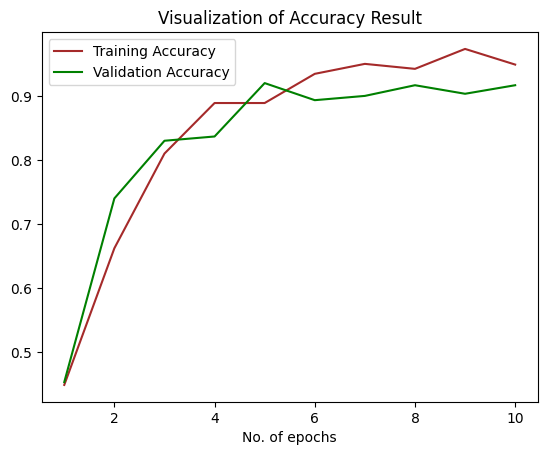

In [25]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='brown',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='green',label='Validation Accuracy')
plt.xlabel('No. of epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()